# University Student Dropout / Non-continuation EDA

**Source:** Office for Students (OfS), England  
**Access method:** Directly from the official website — **no manual dataset download required**

This notebook stops at the **EDA stage only**.

Workflow:

**Official OfS webpage → scrape current dataset link → read ZIP directly from the web → clean data → derive dropout rate → EDA**

The main derived measure is:

\[
\text{Dropout / Non-continuation Rate} = 100 - \text{Continuation Rate}
\]

> Important: OfS data are aggregated group-level outcomes, not one row per individual student.

## 1. Import libraries

In [1]:
# Uncomment once if needed:
# !pip install pandas numpy matplotlib requests beautifulsoup4

import io
import re
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 2. Official OfS source

The notebook first checks the official OfS webpage and searches for the current zipped CSV link.

A fallback official OfS link is included in case the webpage structure changes.

In [2]:
LANDING_PAGE = (
    "https://www.officeforstudents.org.uk/data-and-analysis/"
    "student-characteristics-data/outcomes-data-dashboard/"
)

FALLBACK_ZIP_URL = (
    "https://blobofsproduks.blob.core.windows.net/files/"
    "StudentCharacteristicsData/2025/"
    "student_characteristics_outcomes_datafile_2025.zip"
)

CHUNK_SIZE = 150_000

## 3. Web scraping: find the current dataset link

In [3]:
def find_ofs_zip_url(landing_page=LANDING_PAGE):
    headers = {"User-Agent": "Mozilla/5.0 StudentDropoutResearch/1.0"}
    r = requests.get(landing_page, headers=headers, timeout=60)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    candidates = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        text = a.get_text(" ", strip=True)

        if href.lower().endswith(".zip"):
            candidates.append((text, href))

    for text, href in candidates:
        if "student_characteristics_outcomes" in href.lower():
            return href

    for text, href in candidates:
        if "outcome" in (text + " " + href).lower():
            return href

    raise RuntimeError("Current ZIP link could not be detected.")

try:
    ZIP_URL = find_ofs_zip_url()
    print("Current OfS ZIP detected:")
    print(ZIP_URL)
except Exception as e:
    ZIP_URL = FALLBACK_ZIP_URL
    print("Automatic detection failed, so the official fallback link is used.")
    print(ZIP_URL)

Current OfS ZIP detected:
https://blobofsproduks.blob.core.windows.net/files/StudentCharacteristicsData/2025/student_characteristics_outcomes_datafile_2025.zip


## 4. Read the ZIP directly from the web

This cell loads the compressed data into memory.

You do **not** need to:
- download the dataset manually;
- upload the dataset to Jupyter;
- save the raw CSV locally.

In [4]:
def load_zip_from_web(url):
    headers = {"User-Agent": "Mozilla/5.0 StudentDropoutResearch/1.0"}
    r = requests.get(url, headers=headers, timeout=180)
    r.raise_for_status()

    print(f"Received {len(r.content)/1e6:.1f} MB from OfS.")
    return io.BytesIO(r.content)

zip_buffer = load_zip_from_web(ZIP_URL)
print("ZIP is now available in memory.")

Received 24.8 MB from OfS.
ZIP is now available in memory.


## 5. Inspect the ZIP file

In [5]:
zip_buffer.seek(0)

with zipfile.ZipFile(zip_buffer) as z:
    files = z.namelist()
    csv_files = [f for f in files if f.lower().endswith(".csv")]

    if not csv_files:
        raise RuntimeError("No CSV file was found inside the OfS ZIP.")

    CSV_FILE = max(csv_files, key=lambda x: z.getinfo(x).file_size)
    csv_size = z.getinfo(CSV_FILE).file_size

print("Files in archive:")
for f in files:
    print(" -", f)

print("\nSelected CSV:", CSV_FILE)
print(f"Uncompressed size: {csv_size/1e6:.1f} MB")

Files in archive:
 - student_characteristics_outcomes_datafile_2025.csv

Selected CSV: student_characteristics_outcomes_datafile_2025.csv
Uncompressed size: 489.2 MB


## 6. Read a sample and inspect the columns

In [6]:
zip_buffer.seek(0)

with zipfile.ZipFile(zip_buffer) as z:
    with z.open(CSV_FILE) as f:
        sample = pd.read_csv(f, nrows=50_000, low_memory=False)

print("Sample shape:", sample.shape)
print("\nColumns:")
for i, c in enumerate(sample.columns, 1):
    print(f"{i:>2}. {c}")

display(sample.head())

Sample shape: (50000, 14)

Columns:
 1. lifecyclestage
 2. domicile
 3. level
 4. study_characteristic
 5. Mode_or_subject
 6. Year
 7. Population
 8. Student_Characteristic
 9. Student_Sub_characteristic
10. coverage
11. numerator
12. denominator
13. rate
14. gap


,lifecyclestage,domicile,level,study_characteristic,Mode_or_subject,Year,Population,Student_Characteristic,Student_Sub_characteristic,coverage,numerator,denominator,rate,gap
0,Attainment,All,All undergraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (broad)*,21 and over,"all students, 2010-11 onwards",60,60,87.5%,3.0%
1,Attainment,All,All undergraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (broad)*,Under 21,"all students, 2010-11 onwards",[low],[low],[low],[low]
2,Attainment,All,All undergraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (detailed)*,21 to 25 years,"all students, 2010-11 onwards.",[low],[low],[low],[low]
3,Attainment,All,All undergraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (detailed)*,26 to 30 years,"all students, 2010-11 onwards.",[low],[low],[low],[low]
4,Attainment,All,All undergraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (detailed)*,31 to 40 years,"all students, 2010-11 onwards.",[low],[low],[low],[low]


## Variable definitions used in the OfS outcomes data

The following fields are important for interpreting the outcome data:

| Variable | Definition |
|---|---|
| **Numerator** | The number of students who achieved the specified outcome. For example, for continuation, this is the number of students who continued their studies. |
| **Denominator** | The total number of students included in the relevant group and eligible to be measured for that outcome. |
| **Rate** | The percentage of students achieving the specified outcome, generally calculated as `Numerator / Denominator × 100`. |
| **/** | Indicates that the value is unavailable, suppressed, or otherwise not reported as a usable numeric value. For this EDA, rows containing `/` in the outcome-related numeric fields are removed. |
| **Gap** | The difference between the outcome rate of a particular group and a comparison or reference group, usually expressed in percentage points. |

### Cleaning decision used in this notebook

Because `Rate`, `Numerator`, and `Denominator` are quantitative outcome fields, rows are removed when any of these fields:
- are missing;
- contain `/`;
- contain another string/non-numeric value;
- or contain an invalid numeric value.

This ensures that the EDA is based only on observations with usable quantitative outcome information.

## 7. Detect important fields automatically

Because official datasets can change column names between releases, this notebook attempts to detect:
- outcome / indicator
- academic year
- characteristic
- characteristic group/value
- rate / indicator value
- denominator / population size

In [7]:
def norm(s):
    return re.sub(r"[^a-z0-9]+", "_", str(s).lower()).strip("_")

normalized = {c: norm(c) for c in sample.columns}

def candidates(keywords, exclude=()):
    out = []
    for c, n in normalized.items():
        if any(k in n for k in keywords) and not any(e in n for e in exclude):
            out.append(c)
    return out

def content_score(col, words):
    s = sample[col].astype(str).str.lower()
    return sum(s.str.contains(w, regex=False).mean() for w in words)

outcome_scores = []
for c in sample.select_dtypes(include="object").columns:
    score = content_score(c, ["continuation", "completion", "attainment", "progression"])
    if score > 0:
        outcome_scores.append((score, c))

OUTCOME_COL = max(outcome_scores)[1] if outcome_scores else None

year_cands = candidates(["academic_year", "year", "cohort"])
YEAR_COL = year_cands[0] if year_cands else None

char_cands = candidates(["characteristic", "split", "dimension"], exclude=["value", "group", "category"])
CHARACTERISTIC_COL = char_cands[0] if char_cands else None

group_cands = candidates(["characteristic_value", "characteristic_group", "group", "category", "attribute"])
GROUP_COL = group_cands[0] if group_cands else None

rate_cands = candidates(
    ["indicator_value", "rate", "percentage", "percent", "proportion"],
    exclude=["lower", "upper", "difference", "benchmark"]
)
RATE_COL = rate_cands[0] if rate_cands else None

numerator_cands = candidates(["numerator"])
NUMERATOR_COL = numerator_cands[0] if numerator_cands else None

denom_cands = candidates(["denominator", "population", "base"])
DENOMINATOR_COL = denom_cands[0] if denom_cands else None

print("Detected fields")
print("---------------")
print("Outcome:       ", OUTCOME_COL)
print("Year:          ", YEAR_COL)
print("Characteristic:", CHARACTERISTIC_COL)
print("Group/value:   ", GROUP_COL)
print("Rate:          ", RATE_COL)
print("Numerator:     ", NUMERATOR_COL)
print("Denominator:   ", DENOMINATOR_COL)

Detected fields
---------------
Outcome:        lifecyclestage
Year:           Year
Characteristic: study_characteristic
Group/value:    None
Rate:           rate
Denominator:    Population


### Optional manual override

Only use this if the detected field names above are wrong.

In [ ]:
# Example only:
# OUTCOME_COL = "Outcome"
# YEAR_COL = "Academic year"
# CHARACTERISTIC_COL = "Characteristic"
# GROUP_COL = "Characteristic value"
# RATE_COL = "Rate"
# DENOMINATOR_COL = "Denominator"

## 8. Read only continuation records

The raw file is large, so it is read in chunks.  
Only continuation rows are kept for the dropout/non-continuation EDA.

In [8]:
if OUTCOME_COL is None:
    raise ValueError("Outcome column was not detected. Set OUTCOME_COL manually.")

continuation_parts = []

zip_buffer.seek(0)

with zipfile.ZipFile(zip_buffer) as z:
    with z.open(CSV_FILE) as f:
        for i, chunk in enumerate(pd.read_csv(f, chunksize=CHUNK_SIZE, low_memory=False)):
            mask = chunk[OUTCOME_COL].astype(str).str.contains(
                "continuation", case=False, na=False
            )

            kept = chunk.loc[mask].copy()

            if len(kept):
                continuation_parts.append(kept)

            if (i + 1) % 5 == 0:
                print(f"Processed approximately {(i+1)*CHUNK_SIZE:,} rows")

df = pd.concat(continuation_parts, ignore_index=True)

print("Continuation dataset shape:", df.shape)
display(df.head())

Processed approximately 750,000 rows
Processed approximately 1,500,000 rows
Processed approximately 2,250,000 rows
Continuation dataset shape: (852044, 14)


,lifecyclestage,domicile,level,study_characteristic,Mode_or_subject,Year,Population,Student_Characteristic,Student_Sub_characteristic,coverage,numerator,denominator,rate,gap
0,Continuation,All,All postgraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (broad)*,21 and over,"all students, 2010-11 onwards",480,530,90.8%,NaN
1,Continuation,All,All postgraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (detailed)*,21 to 25 years,"all students, 2010-11 onwards.",[low],[low],[low],[low]
2,Continuation,All,All postgraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (detailed)*,26 to 30 years,"all students, 2010-11 onwards.",90,90,95.6%,NaN
3,Continuation,All,All postgraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (detailed)*,31 to 40 years,"all students, 2010-11 onwards.",210,220,94.2%,NaN
4,Continuation,All,All postgraduate,Mode of study,Apprenticeship,2017-18,Registered,Age (detailed)*,41 to 50 years,"all students, 2010-11 onwards.",140,170,84.4%,NaN


## 9. Clean the rate and create dropout rate

In [9]:
def clean_numeric(s):
    return pd.to_numeric(
        s.astype(str)
         .str.replace("%", "", regex=False)
         .str.replace(",", "", regex=False)
         .str.strip()
         .replace({"": np.nan, "nan": np.nan, "None": np.nan}),
        errors="coerce"
    )

if RATE_COL is None:
    raise ValueError("Rate column was not detected. Set RATE_COL manually.")

df["continuation_rate"] = clean_numeric(df[RATE_COL])

# Convert proportions to percentages if needed.
q95 = df["continuation_rate"].quantile(0.95)
if pd.notna(q95) and q95 <= 1.5:
    df["continuation_rate"] = df["continuation_rate"] * 100

df["dropout_rate"] = 100 - df["continuation_rate"]

if DENOMINATOR_COL is not None:
    df["denominator"] = clean_numeric(df[DENOMINATOR_COL])
else:
    df["denominator"] = np.nan

df["invalid_rate"] = ~df["continuation_rate"].between(0, 100, inclusive="both")

display(df[["continuation_rate", "dropout_rate", "denominator"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
continuation_rate,678804.0,84.607655,10.33485,10.5,79.8,87.2,92.0,99.8
dropout_rate,678804.0,15.392345,10.33485,0.2,8.0,12.8,20.2,89.5
denominator,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9A. Scenario: drop rows where the rate is missing, `"low"`, or another non-numeric string

In some official datasets, a rate field may contain text instead of a numeric value, for example:

```text
low
suppressed
not available
n/a
-
```

Missing and non-numeric rate values cannot be used directly in the EDA because the rate is the main outcome variable.

To keep the original dataset unchanged, this section creates a new DataFrame called:

```python
df_rate_clean
```

The cleaning rule is:

- drop rows where the rate is missing;
- keep rows where the raw rate can be converted to a number;
- drop rows where the raw rate is a text/string value such as `"low"`;
- drop rows where the numeric rate is outside the valid range 0–100.

The original `df` remains unchanged.

In [ ]:
# Inspect the raw rate values before filtering

raw_rate = df[RATE_COL].copy()

# Count missing outcome values separately.
missing_rate_mask = raw_rate.isna()

# Try to convert the original rate field into numeric form.
# Any text such as "low", "suppressed", "n/a", etc. becomes NaN.
rate_numeric_test = pd.to_numeric(
    raw_rate.astype(str)
            .str.replace("%", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip(),
    errors="coerce"
)

# Identify non-missing original values that failed numeric conversion.
string_or_invalid_mask = (
    raw_rate.notna()
    & rate_numeric_test.isna()
)

invalid_rate_values = (
    raw_rate.loc[string_or_invalid_mask]
            .astype(str)
            .str.strip()
            .value_counts()
            .to_frame("rows_removed")
)

print(f"Missing rate values detected: {missing_rate_mask.sum():,}")

print("\nNon-numeric/string rate values detected:")
display(invalid_rate_values.head(30))

## 9B. Create the cleaned-rate DataFrame

This scenario removes all observations where the outcome rate is missing or is not a usable numeric percentage.

For example:

```python
rate = missing      -> remove
        rate = "low"        -> remove
rate = "suppressed" -> remove
rate = "N/A"        -> remove
rate = "85.4"       -> keep
rate = "72%"        -> keep
```

It also removes impossible numeric rates below 0% or above 100%.

In [ ]:
# Preserve original data
df_original = df.copy()

# Create a separate cleaned scenario
df_rate_clean = df.copy()

# Record why observations will be removed
missing_rate_mask = df_rate_clean[RATE_COL].isna()

df_rate_clean["rate_numeric_clean"] = pd.to_numeric(
    df_rate_clean[RATE_COL]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
    errors="coerce"
)

non_numeric_rate_mask = (
    df_rate_clean[RATE_COL].notna()
    & df_rate_clean["rate_numeric_clean"].isna()
)

# If values are stored as proportions (0 to 1), convert to percentages.
q95_clean = df_rate_clean["rate_numeric_clean"].quantile(0.95)

if pd.notna(q95_clean) and q95_clean <= 1.5:
    df_rate_clean["rate_numeric_clean"] *= 100

out_of_range_mask = (
    df_rate_clean["rate_numeric_clean"].notna()
    & ~df_rate_clean["rate_numeric_clean"].between(0, 100, inclusive="both")
)

rows_before = len(df_rate_clean)

# Keep only rows with a non-missing, numeric, valid percentage rate
valid_rate_mask = (
    df_rate_clean["rate_numeric_clean"].notna()
    & df_rate_clean["rate_numeric_clean"].between(0, 100, inclusive="both")
)

df_rate_clean = df_rate_clean.loc[valid_rate_mask].copy()

rows_after = len(df_rate_clean)
rows_removed = rows_before - rows_after

# Recalculate analysis variables from the cleaned outcome rate
df_rate_clean["continuation_rate"] = df_rate_clean["rate_numeric_clean"]
df_rate_clean["dropout_rate"] = 100 - df_rate_clean["continuation_rate"]

print(f"Rows before cleaning:     {rows_before:,}")
print(f"Missing rate rows:        {missing_rate_mask.sum():,}")
print(f"Non-numeric/string rows:  {non_numeric_rate_mask.sum():,}")
print(f"Out-of-range rate rows:   {out_of_range_mask.sum():,}")
print(f"Rows after cleaning:      {rows_after:,}")
print(f"Total rows removed:       {rows_removed:,}")
print(
    f"Percent removed:          "
    f"{(rows_removed / rows_before * 100 if rows_before else 0):.2f}%"
)

## 9C. Compare the original and cleaned scenarios

This makes it easy to confirm whether removing string-rate observations materially changes the dataset.

In [ ]:
comparison = pd.DataFrame({
    "scenario": [
        "Original continuation data",
        "After removing non-numeric/string rates"
    ],
    "rows": [
        len(df_original),
        len(df_rate_clean)
    ],
    "valid_continuation_rates": [
        df_original["continuation_rate"].notna().sum(),
        df_rate_clean["continuation_rate"].notna().sum()
    ],
    "mean_continuation_rate": [
        df_original["continuation_rate"].mean(),
        df_rate_clean["continuation_rate"].mean()
    ],
    "mean_dropout_rate": [
        df_original["dropout_rate"].mean(),
        df_rate_clean["dropout_rate"].mean()
    ]
})

display(comparison.round(2))

## 9D. Continue the EDA using only valid outcome-rate observations

Because the rate is the main outcome variable, all later EDA steps should use only rows where the rate is present, numeric, and within the valid 0–100 range.

The cleaned DataFrame therefore replaces `df` for the rest of the notebook.

In [ ]:
# Use the cleaned dataset for all subsequent EDA steps.
df = df_rate_clean.copy()

print("Subsequent EDA will use df_rate_clean.")
print("Current EDA dataset shape:", df.shape)

## 9E. Remove rows with invalid numerator or denominator values

In addition to removing rows with missing or non-numeric **rate** values, this section also removes rows where:

- `Numerator` is missing or non-numeric;
- `Denominator` is missing or non-numeric;
- either field contains `/` or another string value;
- `Denominator` is zero or negative;
- `Numerator` is negative.

The purpose is to keep only observations with complete, usable quantitative outcome information.

In [ ]:
# Start from the already rate-cleaned dataset
df_outcome_clean = df.copy()

# Detect and clean numerator
if 'NUMERATOR_COL' in globals() and NUMERATOR_COL is not None:
    df_outcome_clean["numerator_numeric_clean"] = pd.to_numeric(
        df_outcome_clean[NUMERATOR_COL]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip(),
        errors="coerce"
    )

    numerator_invalid_mask = (
        df_outcome_clean["numerator_numeric_clean"].isna()
        | (df_outcome_clean["numerator_numeric_clean"] < 0)
    )
else:
    numerator_invalid_mask = pd.Series(
        False, index=df_outcome_clean.index
    )

# Detect and clean denominator
if DENOMINATOR_COL is not None:
    df_outcome_clean["denominator_numeric_clean"] = pd.to_numeric(
        df_outcome_clean[DENOMINATOR_COL]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip(),
        errors="coerce"
    )

    denominator_invalid_mask = (
        df_outcome_clean["denominator_numeric_clean"].isna()
        | (df_outcome_clean["denominator_numeric_clean"] <= 0)
    )
else:
    denominator_invalid_mask = pd.Series(
        False, index=df_outcome_clean.index
    )

rows_before_outcome_clean = len(df_outcome_clean)

print(
    "Invalid numerator rows:",
    int(numerator_invalid_mask.sum())
)
print(
    "Invalid denominator rows:",
    int(denominator_invalid_mask.sum())
)

# Remove rows where either quantitative field is unusable
valid_outcome_mask = (
    ~numerator_invalid_mask
    & ~denominator_invalid_mask
)

df_outcome_clean = df_outcome_clean.loc[
    valid_outcome_mask
].copy()

rows_after_outcome_clean = len(df_outcome_clean)

print(
    f"Rows before numerator/denominator cleaning: "
    f"{rows_before_outcome_clean:,}"
)
print(
    f"Rows after numerator/denominator cleaning:  "
    f"{rows_after_outcome_clean:,}"
)
print(
    f"Rows removed in this step:                  "
    f"{rows_before_outcome_clean - rows_after_outcome_clean:,}"
)

## 9F. Use fully cleaned outcome data for the rest of the EDA

From this point onward, the analysis uses only rows where:
- rate is present and numeric;
- numerator is present and numeric;
- denominator is present, numeric, and greater than zero.

This provides a cleaner basis for comparing student outcomes.

In [ ]:
df = df_outcome_clean.copy()

print("Fully cleaned EDA dataset shape:", df.shape)

## 10. Basic data-quality checks

In [12]:
print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])
print("Duplicate rows:", f"{df.duplicated().sum():,}")
print("Missing continuation rate:", f"{df['continuation_rate'].isna().sum():,}")
print("Invalid rates:", f"{df['invalid_rate'].sum():,}")

if YEAR_COL:
    print("\nAcademic years / periods:")
    print(df[YEAR_COL].dropna().astype(str).value_counts().sort_index())

display(df.dtypes.to_frame("dtype"))

Rows: 852,044
Columns: 17
Duplicate rows: 0
Missing continuation rate: 173,240
Invalid rates: 173,240

Academic years / periods:
Year
2010-11    53344
2011-12    55600
2012-13    58752
2013-14    60056
2014-15    63586
2015-16    70160
2016-17    70256
2017-18    84058
2018-19    83798
2019-20    84206
2020-21    82320
2021-22    81944
2022-23     3964
Name: count, dtype: int64


,dtype
lifecyclestage,object
domicile,object
level,object
study_characteristic,object
Mode_or_subject,object
Year,object
Population,object
Student_Characteristic,object
Student_Sub_characteristic,object
coverage,object


## 11. Missing-value analysis

,missing_pct,missing_count
denominator,100.000000,852044
gap,29.087934,247842
dropout_rate,20.332283,173240
continuation_rate,20.332283,173240
rate,3.671641,31284
lifecyclestage,0.000000,0
domicile,0.000000,0
study_characteristic,0.000000,0
level,0.000000,0
Student_Sub_characteristic,0.000000,0


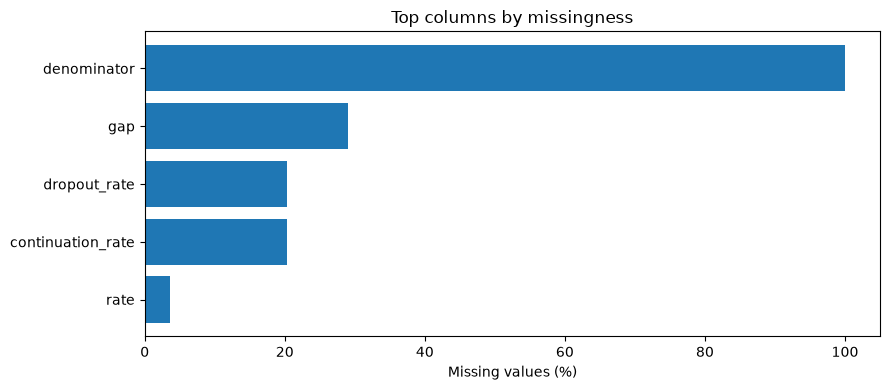

In [11]:
missing = (
    df.isna().mean().mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_pct")
)

missing["missing_count"] = df.isna().sum()
display(missing.head(30))

plot_missing = missing[missing["missing_pct"] > 0].head(25).sort_values("missing_pct")

if not plot_missing.empty:
    plt.figure(figsize=(9, max(4, len(plot_missing) * 0.3)))
    plt.barh(plot_missing.index, plot_missing["missing_pct"])
    plt.xlabel("Missing values (%)")
    plt.title("Top columns by missingness")
    plt.tight_layout()
    plt.show()

## 12. Categorical structure and available factors

In [ ]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

cat_summary = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df[c].nunique(dropna=True) for c in categorical_cols],
    "missing_pct": [df[c].isna().mean() * 100 for c in categorical_cols]
}).sort_values("unique_values")

display(cat_summary)

if CHARACTERISTIC_COL:
    print("\nAvailable characteristics:")
    display(df[CHARACTERISTIC_COL].value_counts(dropna=False).to_frame("rows"))

## 13. Numerical summary

In [ ]:
display(df.select_dtypes(include=np.number).describe().T)

## 14. Distribution of continuation and dropout rates

In [ ]:
valid = df.loc[
    (~df["invalid_rate"]) &
    df["continuation_rate"].notna()
].copy()

plt.figure(figsize=(9, 5))
plt.hist(valid["continuation_rate"], bins=30, edgecolor="black")
plt.xlabel("Continuation rate (%)")
plt.ylabel("Observations")
plt.title("Distribution of continuation rates")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(valid["dropout_rate"], bins=30, edgecolor="black")
plt.xlabel("Dropout / non-continuation rate (%)")
plt.ylabel("Observations")
plt.title("Distribution of estimated dropout rates")
plt.tight_layout()
plt.show()

## 15. Group-size / denominator analysis

In [ ]:
if valid["denominator"].notna().any():
    display(valid["denominator"].describe().to_frame("denominator"))

    positive = valid.loc[valid["denominator"] > 0, "denominator"]

    plt.figure(figsize=(9, 5))
    plt.hist(np.log10(positive), bins=30, edgecolor="black")
    plt.xlabel("log10(denominator)")
    plt.ylabel("Observations")
    plt.title("Distribution of group sizes")
    plt.tight_layout()
    plt.show()
else:
    print("No denominator field was detected.")

## 16. Weighted dropout helper

Rates are weighted by denominator **within the same characteristic**.

Do not sum denominators across different characteristics because the same students can appear in multiple breakdowns.

In [ ]:
def weighted_mean(group, value="dropout_rate", weight="denominator"):
    x = pd.to_numeric(group[value], errors="coerce")
    w = pd.to_numeric(group[weight], errors="coerce")
    keep = x.notna() & w.notna() & (w > 0)

    if keep.sum() == 0:
        return x.mean()

    return np.average(x[keep], weights=w[keep])

## 17. Detect latest academic period

In [ ]:
def latest_period(series):
    vals = series.dropna().astype(str).unique().tolist()

    def extract_start_year(x):
        m = re.search(r"(20\d{2})", x)
        return int(m.group(1)) if m else -1

    return max(vals, key=extract_start_year) if vals else None

LATEST_YEAR = latest_period(df[YEAR_COL]) if YEAR_COL else None
print("Latest period:", LATEST_YEAR)

## 18. Latest-period dropout rate by characteristic and group

In [ ]:
if CHARACTERISTIC_COL and GROUP_COL and YEAR_COL:
    latest = valid.loc[
        valid[YEAR_COL].astype(str) == str(LATEST_YEAR)
    ].copy()

    rates = (
        latest.groupby([CHARACTERISTIC_COL, GROUP_COL], dropna=False)
              .apply(weighted_mean)
              .rename("weighted_dropout_rate")
              .reset_index()
    )

    denom = (
        latest.groupby([CHARACTERISTIC_COL, GROUP_COL], dropna=False)["denominator"]
              .sum(min_count=1)
              .rename("combined_denominator")
              .reset_index()
    )

    latest_group_rates = rates.merge(
        denom,
        on=[CHARACTERISTIC_COL, GROUP_COL],
        how="left"
    )

    display(
        latest_group_rates
        .sort_values([CHARACTERISTIC_COL, "weighted_dropout_rate"],
                     ascending=[True, False])
        .head(100)
    )
else:
    latest_group_rates = pd.DataFrame()
    print("Required fields were not detected.")

## 19. Highest and lowest dropout-rate groups

In [ ]:
MIN_DENOMINATOR = 100

if not latest_group_rates.empty:
    ranked = latest_group_rates.copy()

    if ranked["combined_denominator"].notna().any():
        ranked = ranked.loc[
            ranked["combined_denominator"].fillna(0) >= MIN_DENOMINATOR
        ]

    print("Highest dropout-rate groups")
    display(ranked.sort_values("weighted_dropout_rate", ascending=False).head(20))

    print("\nLowest dropout-rate groups")
    display(ranked.sort_values("weighted_dropout_rate", ascending=True).head(20))

## 20. Visualise one selected student characteristic

In [ ]:
CHARACTERISTIC_TO_PLOT = None

if CHARACTERISTIC_COL:
    available = df[CHARACTERISTIC_COL].dropna().astype(str).unique().tolist()

    preferred = ["Age (Broad)", "Age", "Sex", "Ethnicity", "Disability"]

    for p in preferred:
        exact = [x for x in available if x.lower() == p.lower()]
        if exact:
            CHARACTERISTIC_TO_PLOT = exact[0]
            break

    if CHARACTERISTIC_TO_PLOT is None and available:
        CHARACTERISTIC_TO_PLOT = available[0]

print("Selected characteristic:", CHARACTERISTIC_TO_PLOT)

In [ ]:
if CHARACTERISTIC_TO_PLOT and not latest_group_rates.empty:
    p = latest_group_rates.loc[
        latest_group_rates[CHARACTERISTIC_COL].astype(str)
        == str(CHARACTERISTIC_TO_PLOT)
    ].copy()

    p = p.dropna(subset=["weighted_dropout_rate"])
    p = p.sort_values("weighted_dropout_rate")

    plt.figure(figsize=(10, max(4, len(p) * 0.4)))
    plt.barh(p[GROUP_COL].astype(str), p["weighted_dropout_rate"])
    plt.xlabel("Weighted dropout rate (%)")
    plt.ylabel(CHARACTERISTIC_TO_PLOT)
    plt.title(f"Dropout rate by {CHARACTERISTIC_TO_PLOT} — {LATEST_YEAR}")
    plt.tight_layout()
    plt.show()

## 20A. Divide the data by each student characteristic

Instead of selecting only one characteristic, this section automatically separates the latest-period data into **one DataFrame per student characteristic**.

For example, if the OfS data contain characteristics such as:
- Age
- Sex
- Ethnicity
- Disability
- Free school meals
- Socioeconomic background
- Entry qualification
- Subject of study

the code below creates a separate table for each characteristic.

The result is stored in a Python dictionary called `data_by_characteristic`.

```python
data_by_characteristic["Age"]
data_by_characteristic["Sex"]
data_by_characteristic["Ethnicity"]
```

This makes it easier to analyse each student characteristic separately while still using the same source dataset.

In [ ]:
# Divide the latest-period data into separate DataFrames
# for every available student characteristic.

data_by_characteristic = {}

if CHARACTERISTIC_COL and not latest_group_rates.empty:

    characteristic_names = (
        latest_group_rates[CHARACTERISTIC_COL]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
    )

    for characteristic in characteristic_names:

        characteristic_df = (
            latest_group_rates.loc[
                latest_group_rates[CHARACTERISTIC_COL].astype(str)
                == characteristic
            ]
            .copy()
            .sort_values(
                "weighted_dropout_rate",
                ascending=False
            )
            .reset_index(drop=True)
        )

        data_by_characteristic[characteristic] = characteristic_df

    print(
        f"Created {len(data_by_characteristic)} "
        "separate student-characteristic datasets."
    )

    print("\nAvailable datasets:")
    for characteristic in data_by_characteristic:
        print(" -", characteristic)

else:
    print("Characteristic data are not available.")

## 20B. Summary table for every student characteristic

The following loop displays the groups and weighted dropout rate separately for every student characteristic.

`combined_denominator` shows the number of students represented by the aggregated group where this information is available.

In [ ]:
if data_by_characteristic:

    for characteristic, characteristic_df in data_by_characteristic.items():

        print("\n" + "=" * 80)
        print(f"STUDENT CHARACTERISTIC: {characteristic}")
        print("=" * 80)

        columns_to_show = [
            c for c in [
                GROUP_COL,
                "weighted_dropout_rate",
                "combined_denominator"
            ]
            if c is not None and c in characteristic_df.columns
        ]

        display(
            characteristic_df[columns_to_show]
            .round(2)
        )

## 20C. Plot dropout rate for every student characteristic

A separate bar chart is produced for each characteristic.

To keep the output readable, characteristics containing many categories show the **20 groups with the highest estimated dropout rates**.  
Change `MAX_GROUPS_PER_PLOT` if you want to display more or fewer groups.

In [ ]:
MAX_GROUPS_PER_PLOT = 20

if data_by_characteristic:

    for characteristic, characteristic_df in data_by_characteristic.items():

        plot_df = (
            characteristic_df
            .dropna(subset=["weighted_dropout_rate"])
            .copy()
        )

        # If there are many groups, keep the highest dropout-rate groups.
        if len(plot_df) > MAX_GROUPS_PER_PLOT:
            plot_df = plot_df.nlargest(
                MAX_GROUPS_PER_PLOT,
                "weighted_dropout_rate"
            )

        # Reverse sorting makes the highest bar appear at the top.
        plot_df = plot_df.sort_values(
            "weighted_dropout_rate",
            ascending=True
        )

        if len(plot_df) == 0:
            continue

        plt.figure(
            figsize=(10, max(4, len(plot_df) * 0.35))
        )

        plt.barh(
            plot_df[GROUP_COL].astype(str),
            plot_df["weighted_dropout_rate"]
        )

        plt.xlabel("Weighted dropout rate (%)")
        plt.ylabel(str(characteristic))
        plt.title(
            f"Dropout Rate by {characteristic} — {LATEST_YEAR}"
        )

        plt.tight_layout()
        plt.show()

## 20D. Compare the highest and lowest dropout group within each characteristic

This creates a compact comparison showing:
- the group with the **highest** dropout rate;
- the group with the **lowest** dropout rate;
- the difference between them in percentage points.

This is useful for identifying which student characteristics show the largest differences between their groups.

In [ ]:
characteristic_comparison = []

if data_by_characteristic:

    for characteristic, characteristic_df in data_by_characteristic.items():

        temp = characteristic_df.dropna(
            subset=["weighted_dropout_rate"]
        ).copy()

        # Require at least two groups for a meaningful comparison.
        if len(temp) < 2:
            continue

        highest = temp.loc[
            temp["weighted_dropout_rate"].idxmax()
        ]

        lowest = temp.loc[
            temp["weighted_dropout_rate"].idxmin()
        ]

        characteristic_comparison.append({
            "student_characteristic": characteristic,
            "highest_dropout_group": highest[GROUP_COL],
            "highest_dropout_rate": highest["weighted_dropout_rate"],
            "lowest_dropout_group": lowest[GROUP_COL],
            "lowest_dropout_rate": lowest["weighted_dropout_rate"],
            "gap_percentage_points":
                highest["weighted_dropout_rate"]
                - lowest["weighted_dropout_rate"]
        })

characteristic_comparison = pd.DataFrame(
    characteristic_comparison
)

if not characteristic_comparison.empty:

    characteristic_comparison = (
        characteristic_comparison
        .sort_values(
            "gap_percentage_points",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        characteristic_comparison.round(2)
    )

## 20E. Optional: inspect one characteristic directly

Because each characteristic is stored separately, you can inspect any one of them using its exact name.

First, run:

```python
list(data_by_characteristic.keys())
```

Then select a characteristic, for example:

```python
data_by_characteristic["Age"]
```

The exact available names depend on the current OfS release.

In [ ]:
# Show all available characteristic names.
list(data_by_characteristic.keys())

## 21. Dropout gap within each characteristic

In [ ]:
if not latest_group_rates.empty:
    gaps = (
        latest_group_rates.dropna(subset=["weighted_dropout_rate"])
        .groupby(CHARACTERISTIC_COL)["weighted_dropout_rate"]
        .agg(["min", "max", "mean", "count"])
    )

    gaps["dropout_gap_pp"] = gaps["max"] - gaps["min"]
    gaps = gaps.sort_values("dropout_gap_pp", ascending=False)

    display(gaps.head(30))

    gp = gaps.loc[gaps["count"] >= 2].head(20).sort_values("dropout_gap_pp")

    plt.figure(figsize=(10, max(5, len(gp) * 0.35)))
    plt.barh(gp.index.astype(str), gp["dropout_gap_pp"])
    plt.xlabel("Dropout-rate gap (percentage points)")
    plt.title(f"Largest group gaps by characteristic — {LATEST_YEAR}")
    plt.tight_layout()
    plt.show()

## 22. Dropout trend over time for a selected characteristic

In [ ]:
TREND_CHARACTERISTIC = CHARACTERISTIC_TO_PLOT

if TREND_CHARACTERISTIC and CHARACTERISTIC_COL and GROUP_COL and YEAR_COL:
    tdf = valid.loc[
        valid[CHARACTERISTIC_COL].astype(str) == str(TREND_CHARACTERISTIC)
    ].copy()

    trend = (
        tdf.groupby([YEAR_COL, GROUP_COL], dropna=False)
           .apply(weighted_mean)
           .rename("weighted_dropout_rate")
           .reset_index()
    )

    display(trend.head(30))

    plt.figure(figsize=(11, 6))

    groups = trend[GROUP_COL].dropna().astype(str).unique()

    for g in groups[:12]:
        gdf = trend.loc[trend[GROUP_COL].astype(str) == g]
        plt.plot(
            gdf[YEAR_COL].astype(str),
            gdf["weighted_dropout_rate"],
            marker="o",
            label=g
        )

    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Academic year")
    plt.ylabel("Weighted dropout rate (%)")
    plt.title(f"Dropout trend by group — {TREND_CHARACTERISTIC}")

    if len(groups) <= 12:
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

## 23. Group size versus dropout rate

In [ ]:
if valid["denominator"].notna().any():
    scatter_df = valid.loc[
        valid["denominator"].gt(0) &
        valid["dropout_rate"].notna()
    ].copy()

    if len(scatter_df) > 20_000:
        scatter_df = scatter_df.sample(20_000, random_state=42)

    plt.figure(figsize=(9, 5))
    plt.scatter(
        np.log10(scatter_df["denominator"]),
        scatter_df["dropout_rate"],
        alpha=0.25
    )
    plt.xlabel("log10(denominator)")
    plt.ylabel("Dropout rate (%)")
    plt.title("Group size versus dropout rate")
    plt.tight_layout()
    plt.show()

    print("Spearman correlation:")
    display(scatter_df[["denominator", "dropout_rate"]].corr(method="spearman"))

## 24. Outlier analysis

In [ ]:
q1 = valid["dropout_rate"].quantile(0.25)
q3 = valid["dropout_rate"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = valid.loc[
    (valid["dropout_rate"] < lower) |
    (valid["dropout_rate"] > upper)
].copy()

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Outliers: {len(outliers):,} ({len(outliers)/len(valid)*100:.2f}%)")

show_cols = [
    c for c in [
        YEAR_COL, CHARACTERISTIC_COL, GROUP_COL,
        "continuation_rate", "dropout_rate", "denominator"
    ]
    if c is not None and c in outliers.columns
]

display(
    outliers[show_cols]
    .sort_values("dropout_rate", ascending=False)
    .head(30)
)

## 25. Missing/suppressed outcome rates by characteristic

In [ ]:
if CHARACTERISTIC_COL:
    suppression = (
        df.assign(rate_missing=df["continuation_rate"].isna())
          .groupby(CHARACTERISTIC_COL)["rate_missing"]
          .agg(["mean", "sum", "count"])
    )

    suppression["missing_rate_pct"] = suppression["mean"] * 100
    suppression = suppression.sort_values("missing_rate_pct", ascending=False)

    display(suppression.head(30))

## 25A. Feature necessity analysis

This section evaluates which features are **necessary, conditionally useful, or unnecessary** for the next stage.

Because this notebook stops at EDA, the assessment does **not** train a machine-learning model.

Instead, each feature is checked using:

1. **Missing values** — a feature with very high missingness may be unreliable.
2. **Constant / near-constant values** — these do not help explain variation in dropout rate.
3. **Duplicate or redundant information** — duplicated columns are unnecessary.
4. **Target leakage** — variables directly used to calculate `dropout_rate` must not be used as predictors.
5. **High-cardinality identifiers** — ID-like fields usually do not generalize well.
6. **Association with dropout rate** — categorical and numeric features are evaluated separately.

The target of interest is:

```python
dropout_rate
```

**Important:** `continuation_rate` is mathematically linked to the target:

\[
dropout\_rate = 100 - continuation\_rate
\]

Therefore, `continuation_rate` must **not** be used as a predictor in a later model.

In [ ]:
# Basic feature-quality profile

feature_profile = pd.DataFrame({
    "feature": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_pct": [df[c].isna().mean() * 100 for c in df.columns],
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns]
})

feature_profile["unique_ratio"] = (
    feature_profile["unique_values"] / max(len(df), 1)
)

feature_profile = feature_profile.sort_values(
    ["missing_pct", "unique_values"],
    ascending=[False, False]
).reset_index(drop=True)

display(feature_profile.round(3))

## 25B. Detect features that are clearly unnecessary

The following rules flag columns that should generally **not** be used as predictors:

- the target itself;
- a variable directly used to create the target;
- helper columns created only for cleaning;
- constant columns;
- almost entirely missing columns;
- ID-like columns with nearly one unique value per row.

In [ ]:
TARGET = "dropout_rate"

# Columns known to create leakage or exist only for technical processing.
leakage_or_helper_features = {
    "dropout_rate",
    "continuation_rate",
    "invalid_rate"
}

recommendations = []

for col in df.columns:

    missing_pct = df[col].isna().mean() * 100
    n_unique = df[col].nunique(dropna=True)
    unique_ratio = n_unique / max(len(df), 1)

    reason = []
    decision = "Review"

    # Target / leakage
    if col in leakage_or_helper_features:
        decision = "Remove"
        if col == "dropout_rate":
            reason.append("Target variable, not a predictor")
        elif col == "continuation_rate":
            reason.append("Direct target leakage: dropout_rate = 100 - continuation_rate")
        else:
            reason.append("Technical cleaning/helper field")

    # Constant
    elif n_unique <= 1:
        decision = "Remove"
        reason.append("Constant or no usable variation")

    # Extremely high missingness
    elif missing_pct >= 95:
        decision = "Remove"
        reason.append("At least 95% missing")

    # Likely identifier
    elif unique_ratio >= 0.95 and n_unique > 50:
        decision = "Remove"
        reason.append("Very high cardinality; likely identifier-like")

    # Moderate/high missingness
    elif missing_pct >= 50:
        decision = "Conditional"
        reason.append("High missingness; use only if substantively important")

    else:
        decision = "Candidate"
        reason.append("Passes basic data-quality checks")

    recommendations.append({
        "feature": col,
        "decision": decision,
        "reason": "; ".join(reason),
        "missing_pct": missing_pct,
        "unique_values": n_unique,
        "unique_ratio": unique_ratio
    })

feature_recommendations = pd.DataFrame(recommendations)

display(
    feature_recommendations
    .sort_values(["decision", "missing_pct"], ascending=[True, False])
    .round(3)
)

## 25C. Numeric feature association with dropout rate

For numeric variables, the notebook calculates:

- **Pearson correlation** — linear association;
- **Spearman correlation** — monotonic association.

A higher absolute value indicates a stronger descriptive relationship with dropout rate.

This does **not** prove causation.

In [ ]:
numeric_features = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in leakage_or_helper_features
]

numeric_association = []

for col in numeric_features:

    temp = df[[col, TARGET]].dropna()

    if len(temp) < 3 or temp[col].nunique() <= 1:
        continue

    pearson = temp[col].corr(temp[TARGET], method="pearson")
    spearman = temp[col].corr(temp[TARGET], method="spearman")

    numeric_association.append({
        "feature": col,
        "pearson_corr": pearson,
        "spearman_corr": spearman,
        "abs_spearman": abs(spearman) if pd.notna(spearman) else np.nan
    })

numeric_association = pd.DataFrame(numeric_association)

if not numeric_association.empty:
    numeric_association = numeric_association.sort_values(
        "abs_spearman",
        ascending=False
    )

    display(numeric_association.round(3))
else:
    print("No additional numeric predictors were available.")

## 25D. Categorical feature association with dropout rate

Most OfS variables are categorical.

For each categorical feature, the notebook calculates **eta squared (η²)**:

\[
\eta^2 =
rac{	ext{between-group variation}}
{	ext{total variation}}
\]

Interpretation used here:

- `< 0.01` → very weak
- `0.01–0.06` → small
- `0.06–0.14` → moderate
- `> 0.14` → strong

This is an EDA measure of association, not causal importance.

In [ ]:
def eta_squared(feature, target, data):
    temp = data[[feature, target]].dropna().copy()

    if temp.empty or temp[feature].nunique() <= 1:
        return np.nan

    grand_mean = temp[target].mean()

    total_ss = ((temp[target] - grand_mean) ** 2).sum()

    if total_ss == 0:
        return np.nan

    between_ss = 0

    for _, group in temp.groupby(feature):
        between_ss += (
            len(group)
            * (group[target].mean() - grand_mean) ** 2
        )

    return between_ss / total_ss

categorical_features = [
    c for c in df.select_dtypes(include=["object", "category"]).columns
    if c not in leakage_or_helper_features
]

categorical_association = []

for col in categorical_features:

    eta2 = eta_squared(col, TARGET, df)

    n_unique = df[col].nunique(dropna=True)

    if pd.isna(eta2):
        strength = "Not measurable"
    elif eta2 < 0.01:
        strength = "Very weak"
    elif eta2 < 0.06:
        strength = "Small"
    elif eta2 < 0.14:
        strength = "Moderate"
    else:
        strength = "Strong"

    categorical_association.append({
        "feature": col,
        "unique_values": n_unique,
        "eta_squared": eta2,
        "association_strength": strength
    })

categorical_association = pd.DataFrame(
    categorical_association
).sort_values(
    "eta_squared",
    ascending=False
)

display(categorical_association.round(3))

## 25E. Final feature recommendation table

The code below combines the data-quality checks and association results into a practical recommendation.

### Recommendation categories

**Necessary / Keep**
- important structural variables needed to define the student group or time period;
- useful characteristics with acceptable data quality;
- variables showing meaningful variation in dropout rate.

**Conditional**
- potentially useful, but may have high missingness, high cardinality, or weak association.

**Remove**
- target leakage;
- helper fields;
- constant fields;
- extremely sparse fields;
- identifier-like fields.

Note that a feature should not be removed **only** because its univariate association is weak. It may still become useful in combination with other variables later.

In [ ]:
# Build lookup tables for association strength.
eta_lookup = {}

if "categorical_association" in globals() and not categorical_association.empty:
    eta_lookup = dict(
        zip(
            categorical_association["feature"],
            categorical_association["eta_squared"]
        )
    )

spearman_lookup = {}

if "numeric_association" in globals() and not numeric_association.empty:
    spearman_lookup = dict(
        zip(
            numeric_association["feature"],
            numeric_association["abs_spearman"]
        )
    )

final_feature_analysis = feature_recommendations.copy()

final_decisions = []
final_reasons = []

# Structural variables that are generally needed for interpretation.
structural_features = {
    x for x in [
        YEAR_COL,
        CHARACTERISTIC_COL,
        GROUP_COL,
        DENOMINATOR_COL,
        "denominator"
    ]
    if x is not None
}

for _, row in final_feature_analysis.iterrows():

    feature = row["feature"]
    base_decision = row["decision"]
    reason = row["reason"]

    if base_decision == "Remove":
        final_decisions.append("Remove")
        final_reasons.append(reason)
        continue

    if feature in structural_features:
        final_decisions.append("Necessary / Keep")
        final_reasons.append(
            reason + "; needed to define time period, group, or sample size"
        )
        continue

    if feature in eta_lookup and pd.notna(eta_lookup[feature]):
        eta2 = eta_lookup[feature]

        if eta2 >= 0.06 and row["missing_pct"] < 50:
            final_decisions.append("Necessary / Keep")
            final_reasons.append(
                reason + f"; meaningful categorical association (eta²={eta2:.3f})"
            )

        elif eta2 >= 0.01:
            final_decisions.append("Conditional")
            final_reasons.append(
                reason + f"; small categorical association (eta²={eta2:.3f})"
            )

        else:
            final_decisions.append("Conditional")
            final_reasons.append(
                reason + f"; very weak standalone association (eta²={eta2:.3f})"
            )

    elif feature in spearman_lookup and pd.notna(spearman_lookup[feature]):
        corr = spearman_lookup[feature]

        if corr >= 0.30 and row["missing_pct"] < 50:
            final_decisions.append("Necessary / Keep")
            final_reasons.append(
                reason + f"; useful numeric association (|Spearman|={corr:.3f})"
            )

        elif corr >= 0.10:
            final_decisions.append("Conditional")
            final_reasons.append(
                reason + f"; modest numeric association (|Spearman|={corr:.3f})"
            )

        else:
            final_decisions.append("Conditional")
            final_reasons.append(
                reason + f"; weak standalone numeric association (|Spearman|={corr:.3f})"
            )

    else:
        final_decisions.append("Conditional")
        final_reasons.append(
            reason + "; association could not be fully assessed"
        )

final_feature_analysis["final_recommendation"] = final_decisions
final_feature_analysis["analysis_reason"] = final_reasons

recommendation_order = pd.CategoricalDtype(
    ["Necessary / Keep", "Conditional", "Remove"],
    ordered=True
)

final_feature_analysis["final_recommendation"] = (
    final_feature_analysis["final_recommendation"]
    .astype(recommendation_order)
)

final_feature_analysis = final_feature_analysis.sort_values(
    ["final_recommendation", "missing_pct"]
)

display(
    final_feature_analysis[
        [
            "feature",
            "final_recommendation",
            "analysis_reason",
            "missing_pct",
            "unique_values"
        ]
    ].round(3)
)

## 25F. Create final keep / conditional / remove feature lists

These lists make the feature-selection decision easy to reuse later.

In [ ]:
necessary_features = (
    final_feature_analysis.loc[
        final_feature_analysis["final_recommendation"]
        == "Necessary / Keep",
        "feature"
    ]
    .tolist()
)

conditional_features = (
    final_feature_analysis.loc[
        final_feature_analysis["final_recommendation"]
        == "Conditional",
        "feature"
    ]
    .tolist()
)

remove_features = (
    final_feature_analysis.loc[
        final_feature_analysis["final_recommendation"]
        == "Remove",
        "feature"
    ]
    .tolist()
)

print("NECESSARY / KEEP")
print(necessary_features)

print("\nCONDITIONAL")
print(conditional_features)

print("\nREMOVE")
print(remove_features)

### Interpretation for this project

In this OfS dropout analysis, the most important conceptual distinction is:

- **Target:** `dropout_rate`
- **Must remove from predictors:** `continuation_rate`, because it directly determines the target.
- **Usually keep:** academic year, student characteristic, characteristic group, and denominator/sample-size information.
- **Keep when useful:** demographic, socioeconomic, study, subject, qualification, and other student-characteristic variables that have sufficient observations and meaningful variation.
- **Conditional:** fields with high missingness, very weak standalone association, or too many categories.
- **Remove:** technical/helper columns, constant columns, almost-empty columns, and identifier-like fields.

The final decision table above should be used as the evidence-based feature-selection summary for the EDA stage.

## 26. EDA summary

In [ ]:
print("EDA SUMMARY")
print("=" * 60)
print(f"Continuation observations analysed: {len(valid):,}")
print(f"Median continuation rate: {valid['continuation_rate'].median():.2f}%")
print(f"Mean continuation rate: {valid['continuation_rate'].mean():.2f}%")
print(f"Median estimated dropout rate: {valid['dropout_rate'].median():.2f}%")
print(f"Mean estimated dropout rate: {valid['dropout_rate'].mean():.2f}%")

if YEAR_COL:
    print(f"Latest academic period detected: {LATEST_YEAR}")

if CHARACTERISTIC_COL:
    print(f"Distinct characteristics: {valid[CHARACTERISTIC_COL].nunique()}")

print(
    "\nInterpretation: results are descriptive group-level associations. "
    "They should not be interpreted as individual-level causal effects."
)

# End of notebook

This notebook intentionally stops after **Exploratory Data Analysis (EDA)**.

No machine-learning model, prediction, SHAP, or LIME analysis is included yet.

The raw OfS dataset is accessed directly from the official website during execution, so **you do not need to download the dataset yourself**.